In [4]:
import duckdb
import matplotlib.pyplot as plt

con = duckdb.connect("../blood_data.duckdb")


In [5]:
df = con.execute("select * from historical").df()

df.head()

,inst_code,visit_date,previous_visit,donation_type,donation_location,classification_id,blood_group
0,11-14010001,2006-01-01,1800-08-10,1,M,C,B
1,11-02030085,2006-01-01,2005-12-18,1,U,C,B
2,11-02030085,2006-01-01,2005-06-30,1,U,C,A
3,11-14010001,2006-01-01,1800-08-10,1,M,C,O
4,11-14010001,2006-01-01,1800-08-10,1,M,C,O


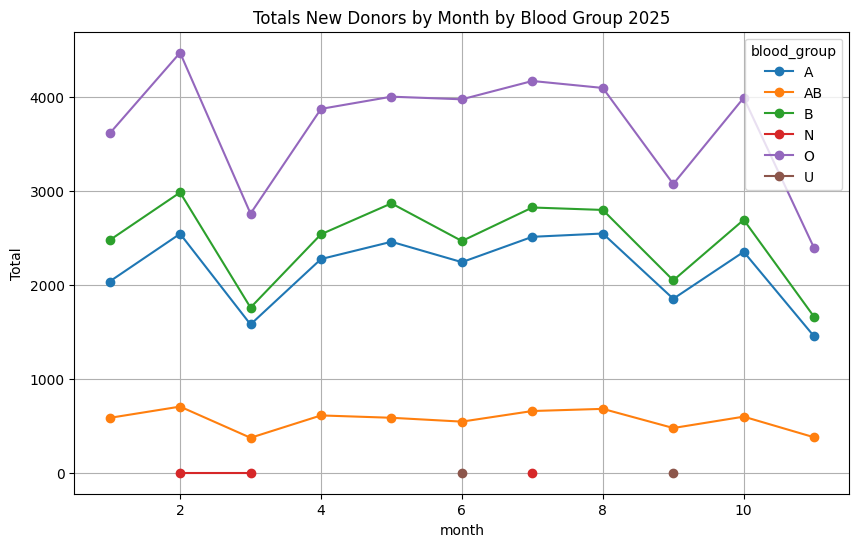

In [41]:
query = "select MONTH(visit_date) as month,blood_group,count(blood_group) as total from historical where YEAR(visit_date) = 2025 and YEAR(previous_visit) = 1800 group by MONTH(visit_date),blood_group order by month,blood_group"

result = con.sql(query).df()

pivot_df = result.pivot(index='month', columns='blood_group', values='total')


pivot_df.plot(marker='o', figsize=(10, 6))

plt.title("Totals New Donors by Month by Blood Group 2025")
plt.ylabel("Total")
plt.grid(True)
plt.show()

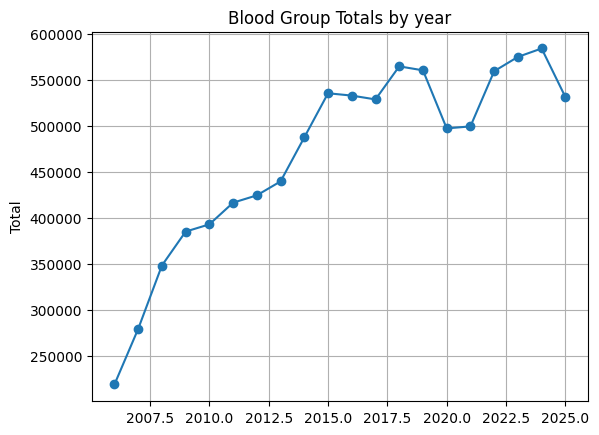

In [50]:
query = "select YEAR(visit_date) as year,count(*) as total from historical group by year order by year"

result = con.sql(query).df()
result
plt.plot(result['year'],result['total'] ,marker='o')

plt.title("Blood Group Totals by year")
plt.ylabel("Total")
plt.grid(True)
plt.show()

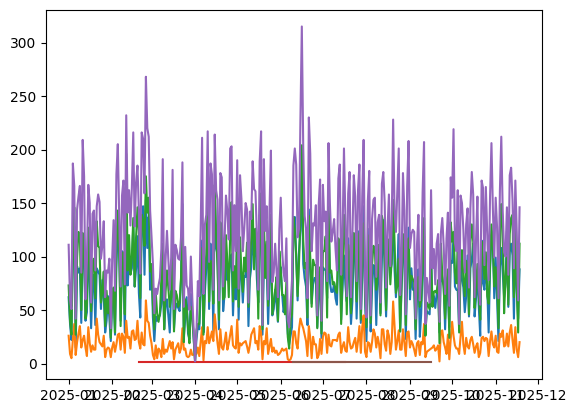

In [31]:
query = """select visit_date as day,blood_group,count(blood_group) as total from historical 
        where 1 
        and YEAR(visit_date) = 2025 
        and YEAR(previous_visit) = 1800 
        group by day,blood_group order by day,blood_group"""

result = con.sql(query).df()

query1 = "select distinct blood_group from historical order by blood_group "
blood_groups = con.execute(query1).df()
df
for bg in blood_groups['blood_group']:
    data = result[result['blood_group'] == bg]
    plt.plot(data['day'],data['total'])

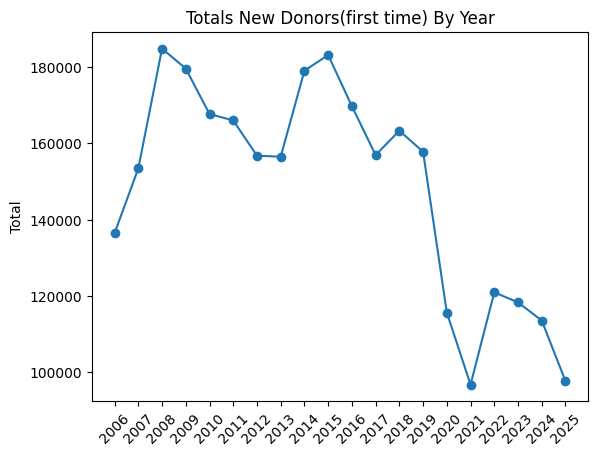

In [57]:
query = "select year(visit_date) as year,count(blood_group) as total from historical where YEAR(previous_visit) = 1800 group by year, order by year"

result = con.sql(query).df()

result


plt.plot(result['year'], result['total'], marker='o')
plt.xticks(result['year'], rotation=45)

plt.title("Totals New Donors(first time) By Year")
plt.ylabel("Total")
# plt.grid(True)
plt.show()

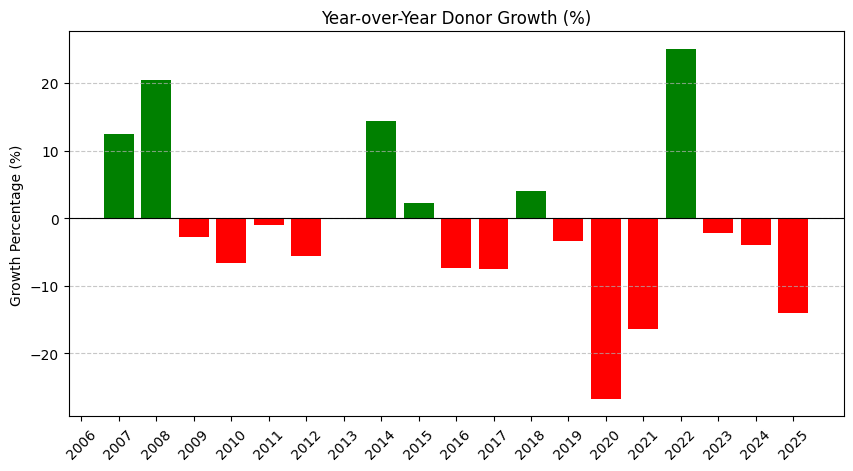

In [62]:
query = "select year(visit_date) as year,count(blood_group) as total from historical where YEAR(previous_visit) = 1800 group by year, order by year"

result = con.sql(query).df()

# result

# 1. Calculate the percentage change
# pct_change() calculates the change from the previous row
result['growth_pct'] = result['total'].pct_change() * 100
result
# 2. Create color logic (Green for up, Red for down)
colors = ['green' if x >= 0 else 'red' for x in result['growth_pct']]

# 3. Plot
plt.figure(figsize=(10, 5))
plt.bar(result['year'], result['growth_pct'], color=colors)

# Formatting
plt.axhline(0, color='black', linewidth=0.8) # Adds a zero line
plt.title("Year-over-Year Donor Growth (%)")
plt.ylabel("Growth Percentage (%)")
plt.xticks(result['year'], rotation=45) # Shows all years
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

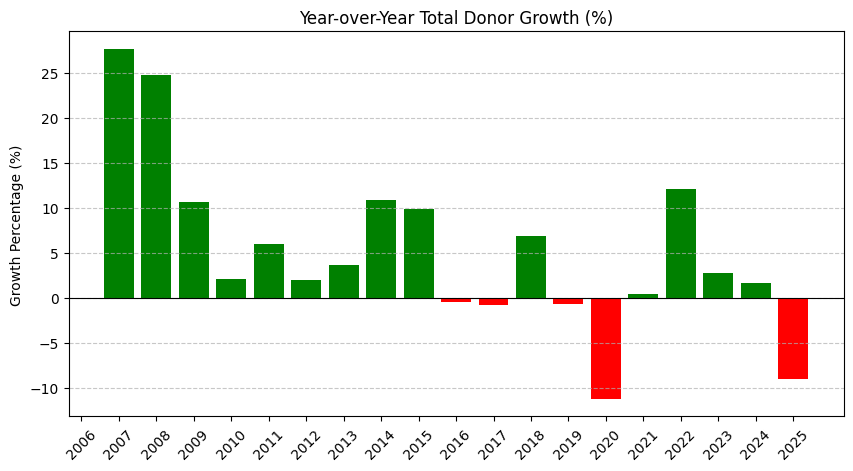

In [66]:
query = "select YEAR(visit_date) as year,count(*) as total from historical group by year order by year"

result = con.sql(query).df()
# result

result['growth_pct'] = result['total'].pct_change() * 100
result
# 2. Create color logic (Green for up, Red for down)
colors = ['green' if x >= 0 else 'red' for x in result['growth_pct']]

# 3. Plot
plt.figure(figsize=(10, 5))
plt.bar(result['year'], result['growth_pct'], color=colors)

# Formatting
plt.axhline(0, color='black', linewidth=0.8) # Adds a zero line
plt.title("Year-over-Year Total Donor Growth (%)")
plt.ylabel("Growth Percentage (%)")
plt.xticks(result['year'], rotation=45) # Shows all years
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

<BarContainer object of 999 artists>

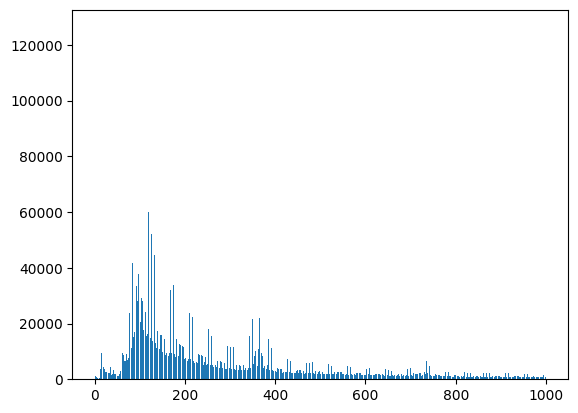

In [96]:
query = """

    select (visit_date - previous_visit) as diff_days , count((visit_date - previous_visit)) as total from historical
    where YEAR(previous_visit) <> 1800
    and  (visit_date - previous_visit) < 1000
    group by diff_days
    order by diff_days
"""

result = con.sql(query).df()
result

plt.bar(result['diff_days'],result['total'])

In [76]:
query = """

    select * from historical
    where 1
    and (visit_date - previous_visit) = 31558
    and YEAR(previous_visit) <> 1800
"""

result = con.sql(query).df()
result

,inst_code,visit_date,previous_visit,donation_type,donation_location,classification_id,blood_group
0,11-12210043,2016-07-13,1930-02-17,1,U,C,B


In [ ]:
con.close()